## Task 2

In [8]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import f1_score
import numpy as np

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test_val': transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 70/15/15
full_dataset = datasets.ImageFolder('data/')
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

train_data.dataset.transform = data_transforms['train']
val_data.dataset.transform = data_transforms['test_val']
test_data.dataset.transform = data_transforms['test_val']

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

num_classes = 8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
def get_model(name):
    if name == 'resnet50':
        model = models.resnet50(pretrained=True)
        for param in model.parameters(): param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    elif name == 'inception_v3':
        model = models.inception_v3(pretrained=True, transform_input=False)
        for param in model.parameters(): param.requires_grad = False
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif name == 'mobilenet_v2':
        model = models.mobilenet_v2(pretrained=True)
        for param in model.parameters(): param.requires_grad = False
        model.classifier[1] = nn.Linear(model.last_channel, num_classes)
        
    return model.to(device)

In [10]:
results = {}

for model_name in ['resnet50', 'inception_v3', 'mobilenet_v2']:
    print(f"\n--- Entrenando {model_name} ---")
    model = get_model(model_name)
    optimizer = optim.Adam(model.parameters() if model_name != 'inception_v3' else model.fc.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(15):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            if model_name == 'inception_v3':
                outputs, aux_outputs = model(inputs)
                loss = criterion(outputs, labels) + 0.4 * criterion(aux_outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()

    # Evaluación Final
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    path = f"{model_name}.pth"
    torch.save(model.state_dict(), path)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    
    # Promedio sobre 100 imágenes
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    start_time = time.time()
    for _ in range(100):
        _ = model(dummy_input)
    avg_inf_time = ((time.time() - start_time) / 100) * 1000 # en ms

    results[model_name] = {'Acc': acc, 'F1': f1, 'Size(MB)': size_mb, 'InfTime(ms)': avg_inf_time}


--- Entrenando resnet50 ---


/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Entrenando inception_v3 ---


/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



--- Entrenando mobilenet_v2 ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/bianca_cal/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:16<00:00, 862kB/s] 


In [11]:
!pip install scikit-learn seaborn matplotlib

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results).T
print("\n--- Comparativa Final para AgriTech Guatemala ---")
print(df_results)

df_results.to_csv('comparativa_modelos_mango.csv')


--- Comparativa Final para AgriTech Guatemala ---
                   Acc        F1   Size(MB)  InfTime(ms)
resnet50      0.995000  0.994823  90.042119     8.962002
inception_v3  0.986667  0.986649  93.280984    15.805640
mobilenet_v2  0.996667  0.996583   8.757335     6.357729


/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bianca_cal/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


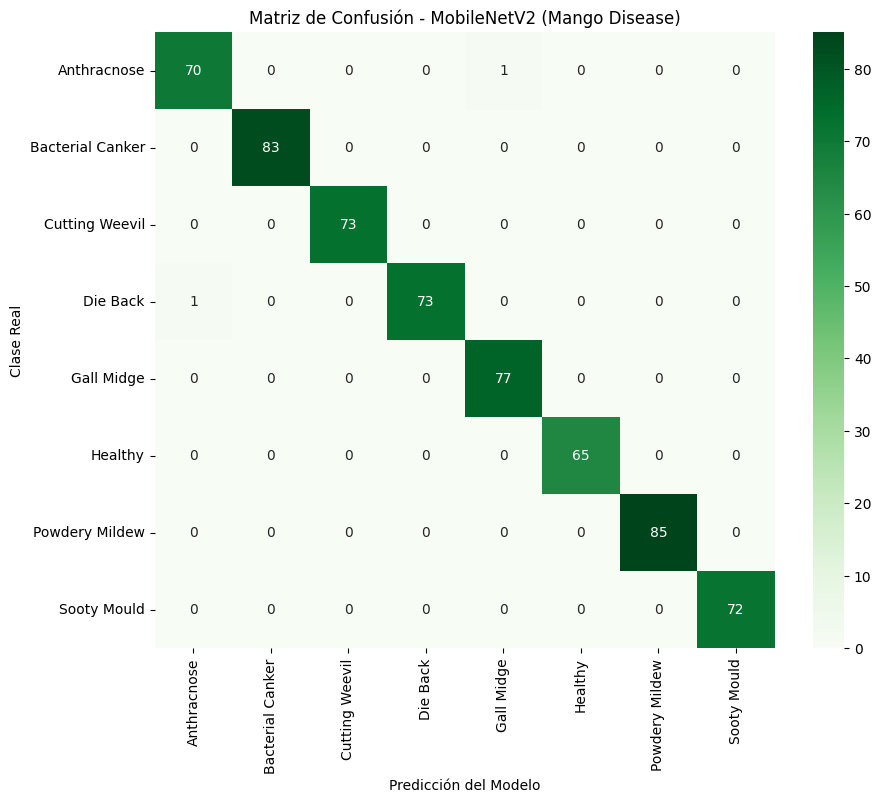

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model = get_model('mobilenet_v2')
model.load_state_dict(torch.load('mobilenet_v2.pth'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
classes = full_dataset.classes

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión - MobileNetV2 (Mango Disease)')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()